# Nigeria's Climate: Basic Exploration

## Step 1: Importing the Data

In this step, we load the required datasets using Pandas and NumPy and perform an initial inspection of the Nigeria's climate dataset.


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


## Step 2: Cleaning the Data

This step involves handling missing values, correcting data types, removing inconsistencies, and preparing the dataset for analysis.


In [17]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


In [18]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 0


In [19]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [20]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct
})

missing_df

,missing,percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [21]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

297


In [22]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.ffill()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


In [23]:
df.to_csv("../data/nigeria_clean.csv", index=False)

## Step 3: Exploration of the Data

We analyze Nigeria's climate data to identify patterns, trends, and seasonal behavior across the years.

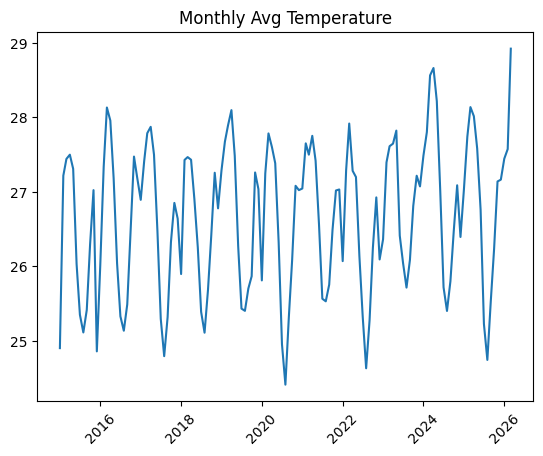

In [24]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["date"], monthly_temp["T2M"])
plt.title("Monthly Avg Temperature")
plt.xticks(rotation=45)
plt.show()

## Interpretation 1: Monthly Average Temperature (2015–2026)

The analysis of Nigeria’s monthly average temperature from 2015 to 2026 shows both seasonal fluctuations and a noticeable long-term upward trend.

Overall, there is a gradual **increasing temperature gradient over time**, resembling a steady upward curve rather than a flat or purely cyclical pattern. This suggests a progressive warming trend across the dataset.

The **lowest temperature values occur around 2020**, marking a temporary dip within the overall warming trajectory. However, even after this low point, the minimum temperatures begin to rise again, indicating that cooler periods are becoming less extreme over time.

The **highest temperature is reached at the start of 2026**, representing the peak of the dataset. This is a concerning observation as it aligns with broader global climate change discussions regarding increasing temperature extremes.

Seasonally, the data shows a repeating pattern within each year:
- Temperatures rise at the beginning of the year  
- Reach a peak mid-cycle  
- Then decline in a near-linear fashion  
- Before rising again into the next year  

This cyclical pattern combined with the upward trend suggests both **seasonal climate structure and long-term warming effects occurring simultaneously**.

In summary, Nigeria’s temperature pattern is characterized by:
- A clear long-term warming trend  
- A temporary low around 2020  
- Record-high peak temperatures by 2026  
- Strong seasonal cycles within each year  

<Figure size 640x480 with 0 Axes>

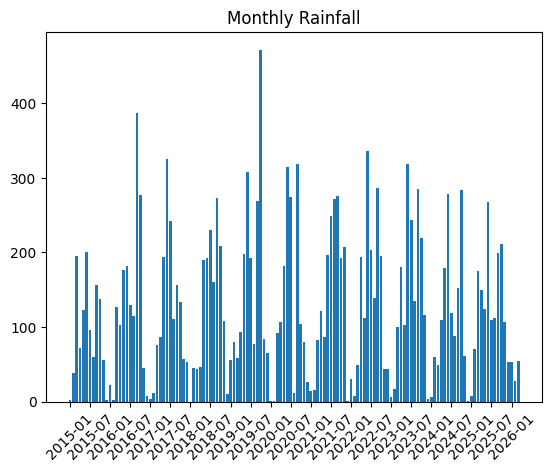

In [25]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
plt.figure()
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

# Create a label column for the x-axis
monthly_rain["label"] = monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(monthly_rain["label"], monthly_rain["PRECTOTCORR"])

step = 6
plt.xticks(
    ticks=range(0, len(monthly_rain), step),
    labels=monthly_rain["label"][::step],
    rotation=45
)

plt.title("Monthly Rainfall")
plt.show()

## Interpretation 2: Monthly Rainfall Patterns (2015–2026)

The monthly rainfall data for Nigeria shows strong variability with alternating periods of increase and decrease in peak rainfall intensity across the years.

The **highest recorded rainfall occurs around 2019**, particularly between the early and mid-months of the year. This represents the peak rainfall period in the dataset and suggests a year of significantly high precipitation.

After 2019, rainfall patterns show a **fluctuating trend**, with alternating increases and decreases in maximum monthly rainfall values. This indicates that Nigeria does not follow a consistent rainfall trend but instead experiences irregular cycles of wet and dry intensity.

The **lowest rainfall occurs around 2015**, where values are extremely low, close to zero, suggesting a very dry starting period in the dataset.

A second notable low point appears around **2023**, indicating another period of reduced rainfall intensity compared to surrounding years.

Overall, the rainfall pattern can be summarized as:
- A major peak in 2019  
- Alternating cycles of increasing and decreasing rainfall intensity  
- Extremely low rainfall in 2015 and again reduced values around 2023  
- High variability in monthly rainfall across the entire period  

This suggests that Nigeria’s rainfall system is highly dynamic, with strong interannual variability rather than a stable long-term pattern.

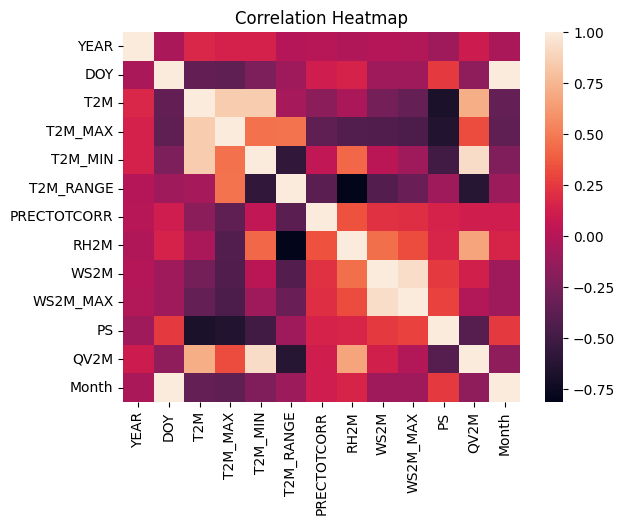

In [26]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

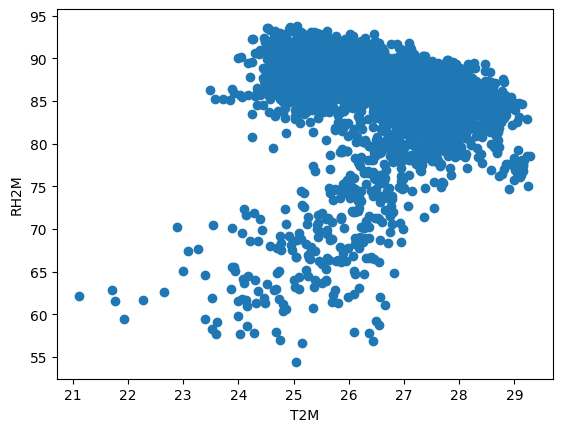

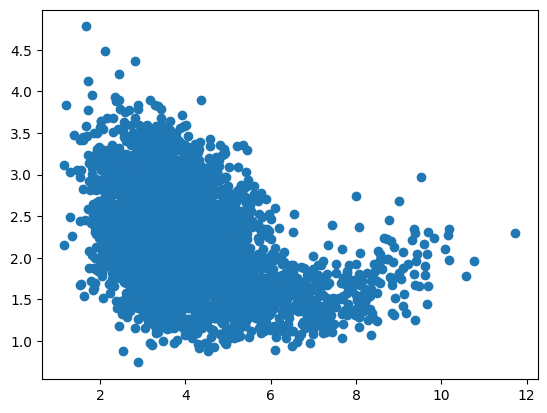

In [27]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

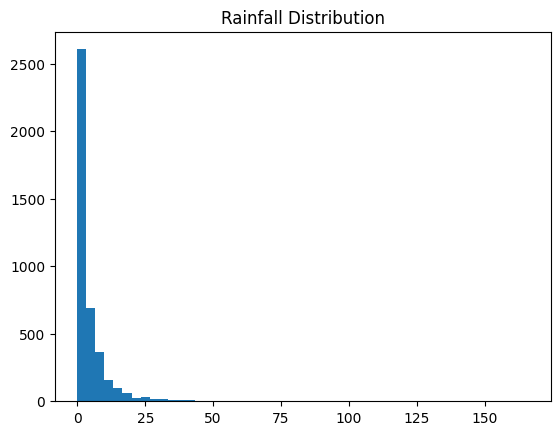

In [28]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.title("Rainfall Distribution")
plt.show()

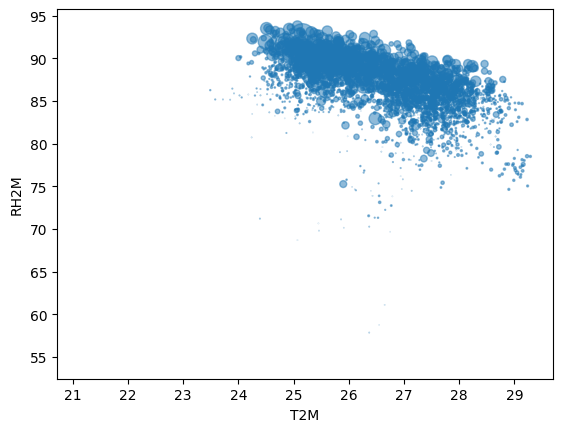

In [29]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()